In [100]:
import sys
import os
from pathlib import Path
import random
import pandas as pd
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from pathlib import Path
from sklearn.decomposition import PCA

# Add source directory to path
sys.path.append(os.path.abspath("../src"))

# Import project utilities
from abstractionssymh.debug_utils import debug_info, debug_error, debug_success
from abstractionssymh.data_loader import parse_json_to_dsl
from abstractionssymh.plot_utils import plot_dsl_with_k3d, plot_dsl_with_matplotlib
from abstractionssymh.dsl_utils import collect_singleton_and_pair_data
from abstractionssymh.abstraction_utils import find_abstractions, Abstraction, integrate_abstractions

In [101]:
# --- Set Project Paths ---
current_path = Path.cwd()
base_project_dir = current_path.parent
dataset_directory = base_project_dir / "src" / "abstractionssymh" / "dataset"

saved_directory = base_project_dir / "src" / "abstractionssymh" / "saved"
saved_directory.mkdir(parents=True, exist_ok=True)

debug_info("Current notebook location:", current_path)
debug_info("Base project directory:", base_project_dir)
debug_info("Target dataset directory:", dataset_directory)
debug_info("Saved directory:", saved_directory)

[INFO] Current notebook location: c:\Users\Amogh\abstraction-discovery\notebookssymh
[INFO] Base project directory: c:\Users\Amogh\abstraction-discovery
[INFO] Target dataset directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\dataset
[INFO] Saved directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved


In [102]:
import pickle
from pathlib import Path

chair_directory = dataset_directory / "Chair"
pickle_file = saved_directory / "all_dsl_shapes.pkl"

# --- Check if pickle exists ---
if pickle_file.exists():
    print(f"Loading DSL shapes from pickle: {pickle_file}")
    with open(pickle_file, "rb") as f:
        all_dsl_shapes = pickle.load(f)
    print(f"Loaded {len(all_dsl_shapes)} DSL shapes from pickle.")
else:
    # --- Step 1: Load DSL objects from JSON files ---
    print("--- Step 1: Loading DSL objects from JSON files ---")
    json_files = sorted(chair_directory.glob("*.json"))
    all_dsl_shapes = {}

    for json_file in json_files:
        try:
            json_content = json_file.read_text(encoding="utf-8")
            dsl_obj = parse_json_to_dsl(json_content)
            all_dsl_shapes[json_file.name] = {
                "dsl": dsl_obj,
                "singleton_params": {},
                "pair_params": {},
            }
        except Exception as e:
            debug_error(f"Failed to load {json_file.name}: {e}")

    print(f"Loaded {len(all_dsl_shapes)} DSL shapes into memory.")

    # --- Step 2: Collect parameters ---
    print("\n--- Step 2: Collecting parameters for each shape ---")
    for name, data in all_dsl_shapes.items():
        dsl_obj = data["dsl"]
        singletons, pairs = collect_singleton_and_pair_data([dsl_obj])
        data["singleton_params"] = singletons
        data["pair_params"] = pairs

    debug_success("Populated singleton and pair parameters for each shape.")

    # --- Step 3: Save to pickle ---
    with open(pickle_file, "wb") as f:
        pickle.dump(all_dsl_shapes, f)
    print(f"Saved all_dsl_shapes with parameters to {pickle_file}")

Loading DSL shapes from pickle: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\all_dsl_shapes.pkl
Loaded 6201 DSL shapes from pickle.


In [103]:
# all_dsl_shapes["Chair_1.json"].keys()

In [104]:
# all_dsl_shapes["Chair_1.json"]["dsl"]

In [105]:
# all_dsl_shapes["Chair_1.json"]["singleton_params"]

In [106]:
# all_dsl_shapes["Chair_1.json"]["pair_params"]

In [107]:
# Paths for pickles
combined_singletons_detailed_pickle = saved_directory / "combined_singletons_detailed.pkl"
combined_pairs_detailed_pickle = saved_directory / "combined_pairs_detailed.pkl"

# --- Step 4: Load or build detailed dictionaries ---
if combined_singletons_detailed_pickle.exists() and combined_pairs_detailed_pickle.exists():
    print("--- Loading detailed dictionaries from pickle ---")
    with open(combined_singletons_detailed_pickle, "rb") as f:
        combined_singletons_detailed = pickle.load(f)
    with open(combined_pairs_detailed_pickle, "rb") as f:
        combined_pairs_detailed = pickle.load(f)
    print("Loaded detailed singleton and pair dictionaries from pickle.")
else:
    print("--- Building detailed dictionaries for singletons and pairs ---")
    combined_singletons_detailed = {}
    combined_pairs_detailed = {}

    for filename, data in all_dsl_shapes.items():
        # SINGLETON parameters
        for pattern_name, param_lists in data["singleton_params"].items():
            for param_list in param_lists or []:
                combined_singletons_detailed.setdefault(pattern_name, []).append({
                    'file': filename,
                    'params': param_list
                })

        # PAIR parameters
        for pattern_name, param_lists in data["pair_params"].items():
            for param_list in param_lists or []:
                combined_pairs_detailed.setdefault(pattern_name, []).append({
                    'file': filename,
                    'params': param_list
                })

    # Save to pickle for future runs
    with open(combined_singletons_detailed_pickle, "wb") as f:
        pickle.dump(combined_singletons_detailed, f)
    with open(combined_pairs_detailed_pickle, "wb") as f:
        pickle.dump(combined_pairs_detailed, f)

    print(f"Built {len(combined_singletons_detailed)} singleton patterns and {len(combined_pairs_detailed)} pair patterns.")
    debug_success("Detailed parameter structures for singletons and pairs created and saved successfully.")

--- Loading detailed dictionaries from pickle ---
Loaded detailed singleton and pair dictionaries from pickle.


In [108]:
# combined_singletons_detailed.keys()

In [109]:
# combined_singletons_detailed["Scale"][:5]

In [110]:
# combined_pairs_detailed.keys()

In [111]:
# combined_pairs_detailed["Rotate(Scale)"][:5]

In [112]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from abstractionssymh.plot_utils import plot_dsl_with_matplotlib_dash

# --- 1. PRECOMPUTE SINGLETON DATA ---
singleton_dfs = {}
for pattern_name, records in combined_singletons_detailed.items():
    df = pd.DataFrame(records)
    params_df = pd.DataFrame(df['params'].to_list(),
                             columns=[f'param_{i}' for i in range(len(records[0]['params']))])
    singleton_dfs[pattern_name] = pd.concat([df[['file']], params_df], axis=1)

# --- 2. PRECOMPUTE PAIR DATA ---
pair_dfs = {}
projection_cache = {}
for pattern_name, records in combined_pairs_detailed.items():
    if not records:
        continue
    df = pd.DataFrame(records)
    param_dim = len(records[0]['params'])
    param_cols = [f'param_{i}' for i in range(param_dim)]
    params_df = pd.DataFrame(df['params'].to_list(), columns=param_cols)
    df = pd.concat([df[['file']], params_df], axis=1)
    pair_dfs[pattern_name] = df

    # Precompute PCA
    n_dims = len(param_cols)
    if n_dims > 3:
        pca = PCA(n_components=3)
        reduced = pca.fit_transform(df[param_cols].values)
        proj_df = pd.DataFrame(reduced, columns=['PC1', 'PC2', 'PC3'])
    else:
        rename_map = {f'param_{i}': f'PC{i+1}' for i in range(n_dims)}
        proj_df = df[param_cols].rename(columns=rename_map)
        for pc in ['PC1','PC2','PC3']:
            if pc not in proj_df:
                proj_df[pc] = 0
    proj_df['file'] = df['file'].values
    projection_cache[pattern_name] = (proj_df, n_dims)

# --- 3. AVAILABLE PATTERNS ---
pattern_types = ['Singleton', 'Pair']

# --- 4. INITIALIZE DASH APP ---
app = dash.Dash(__name__)

# --- 5. LAYOUT ---
app.layout = html.Div(
    style={'backgroundColor': '#1e1e1e', 'color': '#fff', 'padding': '30px', 'fontFamily': 'Arial, sans-serif', 'minHeight': '100vh'},
    children=[
        html.H1("Interactive DSL Pattern Explorer",
                style={'textAlign': 'center', 'marginBottom': '40px', 'color': '#f0a500', 'fontSize': '36px'}),

        # Pattern type dropdown
        html.Div(
            style={'display': 'flex', 'alignItems': 'center', 'justifyContent': 'center', 'marginBottom': '20px', 'gap': '15px'},
            children=[
                html.Label("Pattern Type:", style={'fontSize': '18px', 'fontWeight': 'bold'}),
                dcc.Dropdown(
                    id='pattern-type-dropdown',
                    options=[{'label': t, 'value': t} for t in pattern_types],
                    value='Singleton',
                    style={'color': '#1e1e1e', 'width': '200px', 'borderRadius': '5px'}
                ),
                html.Label("Select Pattern:", style={'fontSize': '18px', 'fontWeight': 'bold'}),
                dcc.Dropdown(id='pattern-selector-dropdown', style={'color': '#1e1e1e', 'width': '300px', 'borderRadius': '5px'})
            ]
        ),

        # Slider
        html.Div(
            style={'marginBottom': '30px', 'textAlign': 'center'},
            children=[
                html.Label("Percentage of points to display:", style={'fontSize': '18px', 'fontWeight': 'bold'}),
                dcc.Slider(
                    id='percent-slider',
                    min=10, max=100, step=10, value=100,
                    marks={i: f'{i}%' for i in range(10, 110, 10)},
                    tooltip={"placement": "bottom", "always_visible": True},
                ),
                html.Div(id='point-count-display', style={'marginTop': '10px', 'fontSize': '16px', 'color': '#f0a500'})
            ]
        ),

        # Main content
        html.Div(
            style={'display': 'flex', 'gap': '20px', 'flexWrap': 'wrap', 'justifyContent': 'center'},
            children=[
                html.Div(
                    style={'flex': '1 1 500px', 'maxWidth': '800px', 'minWidth': '300px',
                           'backgroundColor': '#2b2b2b', 'padding': '15px', 'borderRadius': '10px',
                           'boxShadow': '0 4px 10px rgba(0,0,0,0.3)'},
                    children=[dcc.Graph(id='scatter-plot', style={'height': '600px', 'borderRadius': '10px'})]
                ),
                html.Div(
                    style={'flex': '1 1 500px', 'maxWidth': '800px', 'minWidth': '300px',
                           'backgroundColor': '#2b2b2b', 'padding': '15px', 'borderRadius': '10px',
                           'boxShadow': '0 4px 10px rgba(0,0,0,0.3)',
                           'display': 'flex', 'flexDirection': 'column', 'alignItems': 'center'},
                    children=[
                        html.H3("Selected Chair Visualization", style={'marginTop': '0px', 'color': '#f0a500'}),
                        html.Img(id='dsl-plot-image', style={'width': '100%', 'height': '600px', 'objectFit': 'contain'})
                    ]
                )
            ]
        )
    ]
)

# --- 6. CALLBACKS ---

# Update pattern selector based on type
@app.callback(
    Output('pattern-selector-dropdown', 'options'),
    Output('pattern-selector-dropdown', 'value'),
    Input('pattern-type-dropdown', 'value')
)
def update_pattern_options(pattern_type):
    if pattern_type == 'Singleton':
        options = [{'label': name, 'value': name} for name in singleton_dfs.keys()]
    else:
        options = [{'label': name, 'value': name} for name in pair_dfs.keys()]
    value = options[0]['value'] if options else None
    return options, value

# Update scatter plot
@app.callback(
    [Output('scatter-plot', 'figure'),
     Output('point-count-display', 'children')],
    [Input('pattern-type-dropdown', 'value'),
     Input('pattern-selector-dropdown', 'value'),
     Input('percent-slider', 'value')]
)
def update_scatter(pattern_type, selected_pattern, percent):
    if pattern_type == 'Singleton':
        if not selected_pattern or selected_pattern not in singleton_dfs:
            return {}, ""
        df = singleton_dfs[selected_pattern]
        param_cols = [c for c in df.columns if c.startswith('param_')]
        n_dims = len(param_cols)
        n_total = len(df)
        n_sample = max(1, int(n_total * percent / 100))
        df_sampled = df.sample(n=n_sample, random_state=42)
        if n_dims > 3:
            pca = PCA(n_components=3)
            reduced_data = pca.fit_transform(df_sampled[param_cols].values)
            df_plot = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])
        else:
            df_plot = df_sampled.rename(columns={f'param_{i}': f'PC{i+1}' for i in range(n_dims)})
            for pc in ['PC1','PC2','PC3']:
                if pc not in df_plot: df_plot[pc] = 0
        df_plot['file'] = df_sampled['file'].values
        title = f'"{selected_pattern}" Parameters ({n_dims}D{" -> 3D PCA Projection" if n_dims>3 else ""})'
    else:
        if not selected_pattern or selected_pattern not in projection_cache:
            return {}, ""
        df_plot, n_dims = projection_cache[selected_pattern]
        n_total = len(df_plot)
        n_sample = max(1, int(n_total * percent / 100))
        df_plot = df_plot.sample(n=n_sample, random_state=42)
        title = f'"{selected_pattern}" Parameters ({n_dims}D{" -> 3D PCA Projection" if n_dims>3 else ""})'

    fig = px.scatter_3d(df_plot, x='PC1', y='PC2', z='PC3', hover_data=['file'], custom_data=['file'])
    fig.update_layout(template='plotly_dark', title=title)
    fig.update_traces(marker=dict(size=4, opacity=0.7))

    point_text = f"Showing {n_sample:,} of {n_total:,} points ({percent}%)"
    return fig, point_text

# Update image
@app.callback(
    Output('dsl-plot-image', 'src'),
    Input('scatter-plot', 'clickData')
)
def update_image(clickData):
    if clickData is None:
        return dash.no_update
    clicked_filename = clickData['points'][0]['customdata'][0]
    dsl_obj = all_dsl_shapes[clicked_filename]["dsl"]
    return plot_dsl_with_matplotlib_dash(dsl_obj)

# --- 7. RUN APP ---
app.run(debug=True)


In [113]:
# import dash
# from dash import dcc, html
# from dash.dependencies import Input, Output
# import pandas as pd
# import plotly.express as px
# from sklearn.decomposition import PCA

# from abstractionssymh.plot_utils import plot_dsl_with_matplotlib_dash

# # --- Precompute DataFrames ---
# singleton_dfs = {}
# for pattern_name, records in combined_singletons_detailed.items():
#     df = pd.DataFrame(records)
#     params_df = pd.DataFrame(df['params'].to_list(),
#                              columns=[f'param_{i}' for i in range(len(records[0]['params']))])
#     singleton_dfs[pattern_name] = pd.concat([df[['file']], params_df], axis=1)

# available_patterns = list(combined_singletons_detailed.keys())

# # --- Initialize Dash App ---
# app = dash.Dash(__name__)

# # --- Layout ---
# app.layout = html.Div(
#     style={'backgroundColor': '#1e1e1e', 'color': '#fff', 'padding': '30px', 'fontFamily': 'Arial, sans-serif', 'minHeight': '100vh'},
#     children=[
#         html.H1("Interactive DSL Shape Explorer", style={'textAlign': 'center', 'marginBottom': '40px', 'color': '#f0a500', 'fontSize': '36px'}),

#         # Pattern dropdown
#         html.Div(
#             style={'display': 'flex', 'alignItems': 'center', 'justifyContent': 'center', 'marginBottom': '30px', 'gap': '15px'},
#             children=[
#                 html.Label("Select a Singleton Pattern:", style={'fontSize': '18px', 'fontWeight': 'bold'}),
#                 dcc.Dropdown(
#                     id='pattern-selector-dropdown',
#                     options=[{'label': name, 'value': name} for name in available_patterns],
#                     value=available_patterns[0] if available_patterns else None,
#                     style={'color': '#1e1e1e', 'width': '300px', 'borderRadius': '5px'}
#                 )
#             ]
#         ),

#         # Slider for percentage
#         html.Div(
#             style={'marginBottom': '20px', 'textAlign': 'center'},
#             children=[
#                 html.Label("Percentage of points to display:", style={'fontSize': '18px', 'fontWeight': 'bold'}),
#                 dcc.Slider(
#                     id='percent-slider',
#                     min=10, max=100, step=10, value=100,
#                     marks={i: f'{i}%' for i in range(5, 110, 5)},
#                     tooltip={"placement": "bottom", "always_visible": True},
#                 ),
#                 html.Div(id='point-count-display', style={'marginTop': '10px', 'fontSize': '16px', 'color': '#f0a500'})
#             ]
#         ),

#         # Two-panel layout
#         html.Div(
#             style={'display': 'flex', 'gap': '20px', 'flexWrap': 'wrap', 'justifyContent': 'center'},
#             children=[
#                 # Left: scatter plot
#                 html.Div(
#                     style={'flex': '1 1 500px', 'maxWidth': '800px', 'minWidth': '300px',
#                            'backgroundColor': '#2b2b2b', 'padding': '15px', 'borderRadius': '10px', 'boxShadow': '0 4px 10px rgba(0,0,0,0.3)'},
#                     children=[dcc.Graph(id='scatter-plot', style={'height': '600px', 'borderRadius': '10px'})]
#                 ),
#                 # Right: Matplotlib DSL image
#                 html.Div(
#                     style={'flex': '1 1 500px', 'maxWidth': '800px', 'minWidth': '300px',
#                            'backgroundColor': '#2b2b2b', 'padding': '15px', 'borderRadius': '10px',
#                            'boxShadow': '0 4px 10px rgba(0,0,0,0.3)',
#                            'display': 'flex', 'flexDirection': 'column', 'alignItems': 'center'},
#                     children=[
#                         html.H3("Selected Chair Visualization", style={'marginTop': '0px', 'color': '#f0a500'}),
#                         html.Img(id='dsl-plot-image', style={'width': '100%', 'height': '600px', 'objectFit': 'contain'})
#                     ]
#                 )
#             ]
#         )
#     ]
# )

# # --- Callback: update scatter plot ---
# @app.callback(
#     [Output('scatter-plot', 'figure'),
#      Output('point-count-display', 'children')],
#     [Input('pattern-selector-dropdown', 'value'),
#      Input('percent-slider', 'value')]
# )
# def update_scatter(selected_pattern, percent):
#     if not selected_pattern or selected_pattern not in singleton_dfs:
#         return {}, ""

#     df = singleton_dfs[selected_pattern]
#     param_cols = [c for c in df.columns if c.startswith('param_')]
#     n_dims = len(param_cols)
#     data_values = df[param_cols].values

#     # Subsample based on percent
#     n_total = len(df)
#     n_sample = max(1, int(n_total * percent / 100))
#     df_sampled = df.sample(n=n_sample, random_state=42)

#     if n_dims > 3:
#         pca = PCA(n_components=3)
#         reduced_data = pca.fit_transform(df_sampled[param_cols].values)
#         df_plot = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])
#         df_plot['file'] = df_sampled['file'].values
#         plot_title = f'"{selected_pattern}" Parameters ({n_dims}D -> 3D PCA Projection)'
#     else:
#         df_plot = df_sampled.rename(columns={'param_0': 'PC1', 'param_1': 'PC2', 'param_2': 'PC3'})
#         plot_title = f'"{selected_pattern}" Parameters ({n_dims}D)'

#     fig = px.scatter_3d(df_plot, x='PC1', y='PC2', z='PC3',
#                         hover_data=['file'], custom_data=['file'])
#     fig.update_layout(template='plotly_dark', title=plot_title)
#     fig.update_traces(marker=dict(size=4, opacity=0.7))

#     # Point count text
#     point_text = f"Showing {n_sample:,} of {n_total:,} points ({percent}%)"

#     return fig, point_text

# # --- Callback: update DSL image ---
# @app.callback(
#     Output('dsl-plot-image', 'src'),
#     Input('scatter-plot', 'clickData')
# )
# def update_image(clickData):
#     if clickData is None:
#         return dash.no_update

#     clicked_filename = clickData['points'][0]['customdata'][0]
#     dsl_obj = all_dsl_shapes[clicked_filename]["dsl"]
#     return plot_dsl_with_matplotlib_dash(dsl_obj)


# if not available_patterns:
#     print("No singleton patterns available.")
# else:
#     app.run(debug=True)

In [114]:
# import dash
# from dash import dcc, html
# from dash.dependencies import Input, Output
# import pandas as pd
# import plotly.express as px
# from sklearn.decomposition import PCA

# from abstractionssymh.plot_utils import plot_dsl_with_matplotlib_dash

# # --- 1. PREPARE DATA FOR PAIR PATTERNS ---
# pair_dfs = {}
# projection_cache = {}

# for pattern_name, records in combined_pairs_detailed.items():
#     if not records:
#         continue
#     df = pd.DataFrame(records)
#     param_dim = len(records[0]['params'])
#     param_cols = [f'param_{i}' for i in range(param_dim)]
#     params_df = pd.DataFrame(df['params'].to_list(), columns=param_cols)
#     df = pd.concat([df[['file']], params_df], axis=1)
#     pair_dfs[pattern_name] = df

#     # Precompute PCA projection for caching
#     n_dims = len(param_cols)
#     if n_dims > 3:
#         pca = PCA(n_components=3)
#         reduced = pca.fit_transform(df[param_cols].values)
#         proj_df = pd.DataFrame(reduced, columns=['PC1', 'PC2', 'PC3'])
#     else:
#         # Rename original columns
#         rename_map = {f'param_{i}': f'PC{i+1}' for i in range(n_dims)}
#         proj_df = df[param_cols].rename(columns=rename_map)
#         # Ensure PC1,PC2,PC3 exist
#         for pc in ['PC1', 'PC2', 'PC3']:
#             if pc not in proj_df:
#                 proj_df[pc] = 0

#     proj_df['file'] = df['file'].values
#     projection_cache[pattern_name] = (proj_df, n_dims)

# available_patterns = sorted(list(pair_dfs.keys()))

# # --- 2. INITIALIZE DASH APP ---
# app = dash.Dash(__name__)

# # --- 3. LAYOUT ---
# app.layout = html.Div(
#     style={'backgroundColor': '#1e1e1e', 'color': '#fff', 'padding': '30px',
#            'fontFamily': 'Arial, sans-serif', 'minHeight': '100vh'},
#     children=[
#         html.H1("Interactive DSL Pair Pattern Explorer",
#                 style={'textAlign': 'center', 'marginBottom': '40px',
#                        'color': '#f0a500', 'fontSize': '36px'}),

#         # Dropdown
#         html.Div(
#             style={'display': 'flex', 'alignItems': 'center',
#                    'justifyContent': 'center', 'marginBottom': '20px', 'gap': '15px'},
#             children=[
#                 html.Label("Select a Pair Pattern:",
#                            style={'fontSize': '18px', 'fontWeight': 'bold'}),
#                 dcc.Dropdown(
#                     id='pattern-selector-dropdown',
#                     options=[{'label': name, 'value': name}
#                              for name in available_patterns],
#                     value=available_patterns[0] if available_patterns else None,
#                     style={'color': '#1e1e1e', 'width': '400px',
#                            'borderRadius': '5px'}
#                 )
#             ]
#         ),

#         # Slider
#         html.Div(
#             style={'marginBottom': '30px', 'textAlign': 'center'},
#             children=[
#                 html.Label("Percentage of points to display:",
#                            style={'fontSize': '18px', 'fontWeight': 'bold'}),
#                 dcc.Slider(
#                     id='percent-slider',
#                     min=10, max=100, step=10, value=100,
#                     marks={i: f'{i}%' for i in range(10, 110, 10)},
#                     tooltip={"placement": "bottom", "always_visible": True},
#                 ),
#                 html.Div(id='point-count-display',
#                          style={'marginTop': '10px', 'fontSize': '16px', 'color': '#f0a500'})
#             ]
#         ),

#         # Main content: scatter + image
#         html.Div(
#             style={'display': 'flex', 'gap': '20px', 'flexWrap': 'wrap', 'justifyContent': 'center'},
#             children=[
#                 # Left: Scatter plot
#                 html.Div(
#                     style={'flex': '1 1 500px', 'maxWidth': '800px', 'minWidth': '300px',
#                            'backgroundColor': '#2b2b2b', 'padding': '15px', 'borderRadius': '10px',
#                            'boxShadow': '0 4px 10px rgba(0,0,0,0.3)'},
#                     children=[dcc.Graph(id='scatter-plot',
#                                         style={'height': '600px', 'borderRadius': '10px'})]
#                 ),
#                 # Right: Matplotlib DSL image
#                 html.Div(
#                     style={'flex': '1 1 500px', 'maxWidth': '800px', 'minWidth': '300px',
#                            'backgroundColor': '#2b2b2b', 'padding': '15px', 'borderRadius': '10px',
#                            'boxShadow': '0 4px 10px rgba(0,0,0,0.3)',
#                            'display': 'flex', 'flexDirection': 'column', 'alignItems': 'center'},
#                     children=[
#                         html.H3("Selected Chair Visualization",
#                                 style={'marginTop': '0px', 'color': '#f0a500'}),
#                         html.Img(id='dsl-plot-image',
#                                  style={'width': '100%', 'height': '600px', 'objectFit': 'contain'})
#                     ]
#                 )
#             ]
#         )
#     ]
# )

# # --- 4. CALLBACKS ---
# @app.callback(
#     [Output('scatter-plot', 'figure'),
#      Output('point-count-display', 'children')],
#     [Input('pattern-selector-dropdown', 'value'),
#      Input('percent-slider', 'value')]
# )
# def update_scatter(selected_pattern, percent):
#     if not selected_pattern or selected_pattern not in projection_cache:
#         return {}, ""

#     df_proj, n_dims = projection_cache[selected_pattern]

#     n_total = len(df_proj)
#     n_sample = max(1, int(n_total * percent / 100))
#     df_sampled = df_proj.sample(n=n_sample, random_state=42)

#     plot_title = (f'"{selected_pattern}" Parameters ({n_dims}D -> 3D PCA Projection)'
#                   if n_dims > 3 else
#                   f'"{selected_pattern}" Parameters ({n_dims}D)')

#     fig = px.scatter_3d(df_sampled, x='PC1', y='PC2', z='PC3',
#                         hover_data=['file'], custom_data=['file'])
#     fig.update_layout(template='plotly_dark', title=plot_title)
#     fig.update_traces(marker=dict(size=4, opacity=0.7))

#     point_text = f"Showing {n_sample:,} of {n_total:,} points ({percent}%)"
#     return fig, point_text

# @app.callback(
#     Output('dsl-plot-image', 'src'),
#     Input('scatter-plot', 'clickData')
# )
# def update_image(clickData):
#     if clickData is None:
#         return dash.no_update

#     clicked_filename = clickData['points'][0]['customdata'][0]
#     dsl_obj = all_dsl_shapes[clicked_filename]["dsl"]
#     return plot_dsl_with_matplotlib_dash(dsl_obj)


# if not available_patterns:
#     print("Cannot start Dash app: No pair patterns available.")
# else:
#     app.run(debug=True)


In [115]:
combined_singletons_detailed["Rotate"][0]

{'file': 'Chair_1.json', 'params': [0.0, 0.0, 0.0, 1.0]}

In [116]:
import torch
from pathlib import Path
import re

from abstractionssymh.abstraction_utils import DEVICE, Autoencoder, find_abstractions
from abstractionssymh.debug_utils import debug_info, debug_success, debug_error

# --- A. Prepare Data for Training (Preserve file info) ---
debug_info("--- Preparing data for model training ---")

training_singleton_params = {}
training_singleton_files = {}
for pattern_name, records in combined_singletons_detailed.items():
    training_singleton_params[pattern_name] = [rec['params'] for rec in records]
    training_singleton_files[pattern_name] = [rec['file'] for rec in records]

training_pair_params = {}
training_pair_files = {}
for pattern_name, records in combined_pairs_detailed.items():
    training_pair_params[pattern_name] = [rec['params'] for rec in records]
    training_pair_files[pattern_name] = [rec['file'] for rec in records]

debug_success("Data flattened for autoencoder training, file references preserved.")

# --- B. Train or Load Models ---
models_directory = saved_directory / "models"
models_directory.mkdir(parents=True, exist_ok=True)
models_exist = any(models_directory.iterdir())

singleton_models = {}
pair_models = {}

if models_exist:
    debug_info("--- Models found on disk. Loading from files... ---")

    # --- LOAD SINGLETON MODELS ---
    for name, params in training_singleton_params.items():
        if len(params) < 50: continue
        num_params = len(params[0])
        if num_params <= 1: continue

        safe_filename = re.sub(r'[^\w\-]+', '_', name) + ".pth"
        save_file = models_directory / safe_filename
        if save_file.is_file():
            try:
                model = Autoencoder(num_params, max(1, num_params - 1)).to(DEVICE)
                model.load_state_dict(torch.load(save_file))
                model.eval()
                singleton_models[name] = model
                debug_success(f"Loaded singleton model for '{name}'")
            except Exception as e:
                debug_error(f"Failed to load singleton model for '{name}': {e}")

    # --- LOAD PAIR MODELS ---
    for name, params in training_pair_params.items():
        if len(params) < 50: continue
        num_params = len(params[0])
        if num_params <= 1: continue

        safe_filename = re.sub(r'[^\w\-]+', '_', name) + ".pth"
        save_file = models_directory / safe_filename
        if save_file.is_file():
            try:
                model = Autoencoder(num_params, max(1, num_params - 1)).to(DEVICE)
                model.load_state_dict(torch.load(save_file))
                model.eval()
                pair_models[name] = model
                debug_success(f"Loaded pair model for '{name}'")
            except Exception as e:
                debug_error(f"Failed to load pair model for '{name}': {e}")

else:
    debug_info("--- No models found. Starting training process... ---")

    debug_info("Training singleton models...")
    singleton_models = find_abstractions(
        training_singleton_params, 
        structure_type="SINGLETONS", 
        min_examples=50, 
        epochs=1
    )

    debug_info("Training pair models...")
    pair_models = find_abstractions(
        training_pair_params, 
        structure_type="PAIRS", 
        min_examples=50, 
        epochs=1
    )

    # --- SAVE MODELS ---
    for name, model in singleton_models.items():
        safe_filename = re.sub(r'[^\w\-]+', '_', name) + ".pth"
        torch.save(model.state_dict(), models_directory / safe_filename)
        debug_success(f"Saved singleton model for '{name}'")

    for name, model in pair_models.items():
        safe_filename = re.sub(r'[^\w\-]+', '_', name) + ".pth"
        torch.save(model.state_dict(), models_directory / safe_filename)
        debug_success(f"Saved pair model for '{name}'")

debug_success(
    f"--- Workflow complete. {len(singleton_models)} singleton and {len(pair_models)} pair models are ready. ---"
)


[INFO] --- Preparing data for model training ---
[SUCCESS] Data flattened for autoencoder training, file references preserved.
[INFO] --- Models found on disk. Loading from files... ---
[INFO] Initializing Autoencoder: input_dim=4, hidden_dim=3
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded singleton model for 'Rotate'
[INFO] Initializing Autoencoder: input_dim=3, hidden_dim=2
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded singleton model for 'Scale'
[INFO] Initializing Autoencoder: input_dim=3, hidden_dim=2
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded singleton model for 'Translate'
[INFO] Initializing Autoencoder: input_dim=6, hidden_dim=5
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded singleton model for 'SymRef'
[INFO] Initializing Autoencoder: input_dim=6, hidden_dim=5
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded singleton model for 'SymRot'
[INFO] Initializing Autoencoder: input_dim=3, h

In [124]:
# --- 1. PRECOMPUTE SINGLETON DATA ---
singleton_dfs = {}
for pattern_name, records in combined_singletons_detailed.items():
    df = pd.DataFrame(records)
    params_df = pd.DataFrame(df['params'].to_list(),
                             columns=[f'param_{i}' for i in range(len(records[0]['params']))])
    singleton_dfs[pattern_name] = pd.concat([df[['file']], params_df], axis=1)

# --- 2. PRECOMPUTE PAIR DATA ---
pair_dfs = {}
projection_cache = {}
for pattern_name, records in combined_pairs_detailed.items():
    if not records:
        continue
    df = pd.DataFrame(records)
    param_dim = len(records[0]['params'])
    param_cols = [f'param_{i}' for i in range(param_dim)]
    params_df = pd.DataFrame(df['params'].to_list(), columns=param_cols)
    df = pd.concat([df[['file']], params_df], axis=1)
    pair_dfs[pattern_name] = df

    # Precompute PCA
    n_dims = len(param_cols)
    if n_dims > 3:
        pca = PCA(n_components=3)
        reduced = pca.fit_transform(df[param_cols].values)
        proj_df = pd.DataFrame(reduced, columns=['PC1', 'PC2', 'PC3'])
    else:
        rename_map = {f'param_{i}': f'PC{i+1}' for i in range(n_dims)}
        proj_df = df[param_cols].rename(columns=rename_map)
        for pc in ['PC1','PC2','PC3']:
            if pc not in proj_df:
                proj_df[pc] = 0
    proj_df['file'] = df['file'].values
    projection_cache[pattern_name] = (proj_df, n_dims)

# --- 3. AVAILABLE PATTERNS ---
pattern_types = ['Singleton', 'Pair']

# --- 4. INITIALIZE DASH APP ---
app = dash.Dash(__name__)

# --- 5. LAYOUT ---
app.layout = html.Div(
    style={'backgroundColor': '#1e1e1e', 'color': '#fff', 'padding': '30px', 'fontFamily': 'Arial, sans-serif'},
    children=[
        html.H1("Interactive DSL Abstraction Explorer",
                style={'textAlign': 'center', 'marginBottom': '40px', 'color': '#f0a500'}),

        # --- Top Controls: Dropdowns and Slider ---
        html.Div(
            style={'display': 'flex', 'alignItems': 'center', 'justifyContent': 'center', 'marginBottom': '20px', 'gap': '15px'},
            children=[
                html.Label("Pattern Type:"),
                dcc.Dropdown(
                    id='pattern-type-dropdown',
                    options=[{'label': t, 'value': t} for t in pattern_types],
                    value='Singleton',
                    style={'color': '#1e1e1e', 'width': '200px'}
                ),
                html.Label("Select Pattern:"),
                dcc.Dropdown(id='pattern-selector-dropdown', style={'color': '#1e1e1e', 'width': '300px'})
            ]
        ),
        html.Div(
            style={'maxWidth': '800px', 'margin': '0 auto 30px auto'},
            children=[
                html.Label("Percentage of points to display:"),
                dcc.Slider(
                    id='percent-slider',
                    min=10, max=100, step=10, value=100,
                    marks={i: f'{i}%' for i in range(10, 110, 10)},
                    tooltip={"placement": "bottom", "always_visible": True},
                ),
                html.Div(id='point-count-display', style={'textAlign': 'center', 'marginTop': '10px', 'color': '#f0a500'})
            ]
        ),

        # --- Main Scatter Plot ---
        html.Div(
            style={
                'backgroundColor': '#2b2b2b', 'padding': '15px', 'borderRadius': '10px',
                'boxShadow': '0 4px 10px rgba(0,0,0,0.3)', 'marginBottom': '30px'
            },
            children=[dcc.Graph(id='scatter-plot', style={'height': '600px'})]
        ),

        # --- Bottom Two-Column Layout for DSL Details ---
        html.Div(
            style={'display': 'flex', 'gap': '30px', 'justifyContent': 'center'},
            children=[
                # Left Column: Original DSL
                html.Div(
                    style={
                        'flex': '1', 'maxWidth': '700px', 'backgroundColor': '#2b2b2b',
                        'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0 4px 10px rgba(0,0,0,0.3)'
                    },
                    children=[
                        html.H4("Selected Chair (Original DSL)", style={"color": "#f0a500", "textAlign": "center"}),
                        html.Pre(id='selected-dsl-text', style={'whiteSpace': 'pre-wrap', 'wordWrap': 'break-word', 'backgroundColor': '#1e1e1e', 'padding': '10px', 'borderRadius': '5px', 'minHeight': '150px'}),
                        html.Img(id='selected-dsl-plot', style={'width': '100%', 'height': '400px', 'objectFit': 'contain', 'marginTop': '15px'})
                    ]
                ),
                # Right Column: Abstracted DSL
                html.Div(
                    style={
                        'flex': '1', 'maxWidth': '700px', 'backgroundColor': '#2b2b2b',
                        'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0 4px 10px rgba(0,0,0,0.3)'
                    },
                    children=[
                        html.H4("Abstracted Version", style={"color": "#f0a500", "textAlign": "center"}),
                        html.Pre(id='abstracted-dsl-text', style={'whiteSpace': 'pre-wrap', 'wordWrap': 'break-word', 'backgroundColor': '#1e1e1e', 'padding': '10px', 'borderRadius': '5px', 'minHeight': '150px'}),
                        html.Img(id='abstracted-dsl-plot', style={'width': '100%', 'height': '400px', 'objectFit': 'contain', 'marginTop': '15px'})
                    ]
                )
            ]
        )
    ]
)

# --- 6. CALLBACKS ---

# Callback 1: Update pattern selector dropdown based on pattern type
@app.callback(
    Output('pattern-selector-dropdown', 'options'),
    Output('pattern-selector-dropdown', 'value'),
    Input('pattern-type-dropdown', 'value')
)
def update_pattern_options(pattern_type):
    if pattern_type == 'Singleton':
        options = [{'label': name, 'value': name} for name in singleton_dfs.keys()]
    else:
        options = [{'label': name, 'value': name} for name in pair_dfs.keys()]
    value = options[0]['value'] if options else None
    return options, value

# Callback 2: Update the main scatter plot
@app.callback(
    Output('scatter-plot', 'figure'),
    Output('point-count-display', 'children'),
    Input('pattern-type-dropdown', 'value'),
    Input('pattern-selector-dropdown', 'value'),
    Input('percent-slider', 'value')
)
def update_scatter(pattern_type, selected_pattern, percent):
    if not selected_pattern:
        return {}, "Please select a pattern"

    if pattern_type == 'Singleton':
        if selected_pattern not in singleton_dfs:
            raise dash.exceptions.PreventUpdate
        df = singleton_dfs[selected_pattern]
        param_cols = [c for c in df.columns if c.startswith('param_')]
        n_dims = len(param_cols)
        n_total = len(df)
        n_sample = max(1, int(n_total * percent / 100))
        df_sampled = df.sample(n=n_sample, random_state=42)
        if n_dims > 3:
            pca = PCA(n_components=3)
            reduced_data = pca.fit_transform(df_sampled[param_cols].values)
            df_plot = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])
        else:
            df_plot = df_sampled.rename(columns={f'param_{i}': f'PC{i+1}' for i in range(n_dims)})
            for pc in ['PC1','PC2','PC3']:
                if pc not in df_plot: df_plot[pc] = 0
        df_plot['file'] = df_sampled['file'].values
    else: # Pair type
        if selected_pattern not in projection_cache:
            raise dash.exceptions.PreventUpdate
        df_plot, n_dims = projection_cache[selected_pattern]
        n_total = len(df_plot)
        n_sample = max(1, int(n_total * percent / 100))
        df_plot = df_plot.sample(n=n_sample, random_state=42)

    title = f'"{selected_pattern}" Parameters ({n_dims}D{" -> 3D PCA Projection" if n_dims>3 else ""})'
    fig = px.scatter_3d(df_plot, x='PC1', y='PC2', z='PC3', hover_data=['file'], custom_data=['file'])
    fig.update_layout(template='plotly_dark', title={'text': title, 'x': 0.5})
    fig.update_traces(marker=dict(size=4, opacity=0.8))

    point_text = f"Showing {n_sample:,} of {n_total:,} points ({percent}%)"
    return fig, point_text

# Callback 3: Update the bottom two columns when a point is clicked on the scatter plot
@app.callback(
    Output('selected-dsl-text', 'children'),
    Output('selected-dsl-plot', 'src'),
    Output('abstracted-dsl-text', 'children'),
    Output('abstracted-dsl-plot', 'src'),
    Input('scatter-plot', 'clickData')
)
def update_details_on_click(clickData):
    if clickData is None:
        # Prevents the callback from firing on initial load
        return "Click a point on the scatter plot to see details.", "", "Details will appear here.", ""

    # --- Get Original DSL ---
    clicked_filename = clickData['points'][0]['customdata'][0]
    original_dsl = all_dsl_shapes[clicked_filename]["dsl"]

    # --- Get Abstracted DSL ---
    abstracted_dsl = integrate_abstractions(
        original_dsl, singleton_models, pair_models, error_threshold=0.01
    )

    # --- Generate Plots ---
    orig_src = plot_dsl_with_matplotlib_dash(original_dsl)
    abs_src = plot_dsl_with_matplotlib_dash(abstracted_dsl)

    return str(original_dsl), orig_src, str(abstracted_dsl), abs_src

# --- 7. RUN APP ---
if __name__ == '__main__':
    app.run(debug=True)

[INFO] Expanding abstraction: Abs(Translate(Rotate), dim=6), compressed_params=[1.4013206958770752, 0.7201817631721497, -0.5526724457740784, -0.20576651394367218, -1.6058658361434937, 0.36952680349349976](
    Scale(lengths=[0.760, 0.106, 0.680])
        Box(label=1)
)
[SUCCESS] Reconstructed params: [0.01620309427380562, -0.09141319990158081, 0.15216420590877533, 0.0015405938029289246, 0.0053549520671367645, -0.003134213387966156, 0.9996623396873474]
[INFO] [INSTANTIATE] Pattern: 'Translate(Rotate)' | params=[0.01620309427380562, -0.09141319990158081, 0.15216420590877533, 0.0015405938029289246, 0.0053549520671367645, -0.003134213387966156, 0.9996623396873474] | #children=1
[SUCCESS] Successfully rebuilt node: Translate(center=[0.016, -0.091, 0.152])
    Rotate(quat=[0.0015, 0.0054, -0.0031, 0.9997])
        Scale(lengths=[0.760, 0.106, 0.680])
            Box(label=1)
[INFO] Expanding abstraction: Abs(Translate(Rotate), dim=6), compressed_params=[1.3513307571411133, 0.6529079079627991

In [73]:
## CLUSTER!

# import numpy as np
# import k3d
# import hdbscan
# import umap
# from k3d.colormaps import matplotlib_color_maps

# def run_hdbscan(data, min_cluster_size):
#     print(f"Running HDBSCAN with min_cluster_size={min_cluster_size}...")

#     clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
#     labels = clusterer.fit_predict(data)
    
#     n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
#     n_noise = list(labels).count(-1)

#     print(f"Found {n_clusters} clusters and {n_noise} noise points.")
#     return labels


# def plot_clusters(data, labels, param_name):
#     dim = data.shape[1]
#     plot_title = f'HDBSCAN clusters for {param_name}'
    
#     if dim == 3:
#         positions_3d = data
#     elif dim > 3:
#         print(f"Data is {dim}D. Reducing to 3D with UMAP for visualization.")
#         reducer = umap.UMAP(n_components=3)
#         positions_3d = reducer.fit_transform(data)
#         plot_title += ' (UMAP Projection)'
#     else:
#         print(f"Data is {dim}D. Cannot create a 3D visualization.")
#         return

#     # Create and display the k3d plot
#     plot = k3d.plot(name=plot_title)
#     points_plot = k3d.points(
#         positions=positions_3d.astype(np.float32),
#         point_size=0.05,
#         attribute=labels.astype(np.float32),
#         color_map=matplotlib_color_maps.Paired,
#         color_range=[np.min(labels), np.max(labels)]
#     )
#     plot += points_plot
#     plot.display()


# def save_clusters_to_dict(original_data, labels, param_name, target_dict):
#     unique_labels = set(labels)
#     print(f"Saving clusters for {param_name}...")
#     for cluster_id in unique_labels:
#         if cluster_id == -1: # Ignore noise points
#             continue
            
#         mask = (labels == cluster_id)
#         key = f"{param_name}_cluster{cluster_id}"
#         target_dict[key] = original_data[mask]
#         print(f"  - Saved {len(original_data[mask])} samples to '{key}'")

# singleton_params_clustered = {}


# # --- Workflow for "Scale" (3D data) ---
# print("--- Processing Scale ---")
# scale_array = np.array(singletons["Scale"])
# # Step 1: Cluster the data
# scale_labels = run_hdbscan(scale_array, min_cluster_size=50)
# # Step 2: Visualize the clusters
# plot_clusters(scale_array, scale_labels, "Scale")
# # Step 3: Save the results
# save_clusters_to_dict(scale_array, scale_labels, "Scale", singleton_params_clustered)
# print("-" * 30 + "\n")


# # --- Workflow for "Rotate" (4D data) ---
# print("--- Processing Rotate ---")
# rotate_array = np.array(singletons["Rotate"])
# # Step 1: Cluster the data
# rotate_labels = run_hdbscan(rotate_array, min_cluster_size=30)
# # Step 2: Visualize the clusters
# plot_clusters(rotate_array, rotate_labels, "Rotate")
# # Step 3: Save the results
# save_clusters_to_dict(rotate_array, rotate_labels, "Rotate", singleton_params_clustered)
# print("-" * 30 + "\n")


# # --- Verify the final output ---
# print("✅ Processing complete! Final clustered dictionary keys:")
# print(list(singleton_params_clustered.keys()))

In [ ]:
# singleton_params_clustered

In [ ]:
# singleton_params

[INFO] --- Testing Abstraction on: Chair_6043.json ---

--- ORIGINAL CHAIR DSL ---
Union(
    Union(
        Translate(center=[0.002, -0.079, 0.143])
            Rotate(quat=[-0.0381, -0.0000, 0.0026, 0.9993])
                Scale(lengths=[0.823, 0.273, 0.779])
                    Box(label=1),
        SymRef(
            plane=[0.996, -0.092, -0.013],
            point_on_plane=[0.005, -0.329, -0.194]
        )(
            Union(
                Translate(center=[0.395, -0.365, -0.199])
                    Rotate(quat=[0.1459, 0.0100, -0.0054, 0.9892])
                        Scale(lengths=[0.050, 0.890, 0.151])
                            Box(label=2),
                Translate(center=[-0.378, -0.272, 0.160])
                    Rotate(quat=[-0.2774, 0.0216, -0.0057, 0.9605])
                        Scale(lengths=[0.070, 1.255, 0.252])
                            Box(label=2)
            )
        )
    ),
    Union(
        Translate(center=[0.003, 0.234, -0.109])
            Rota

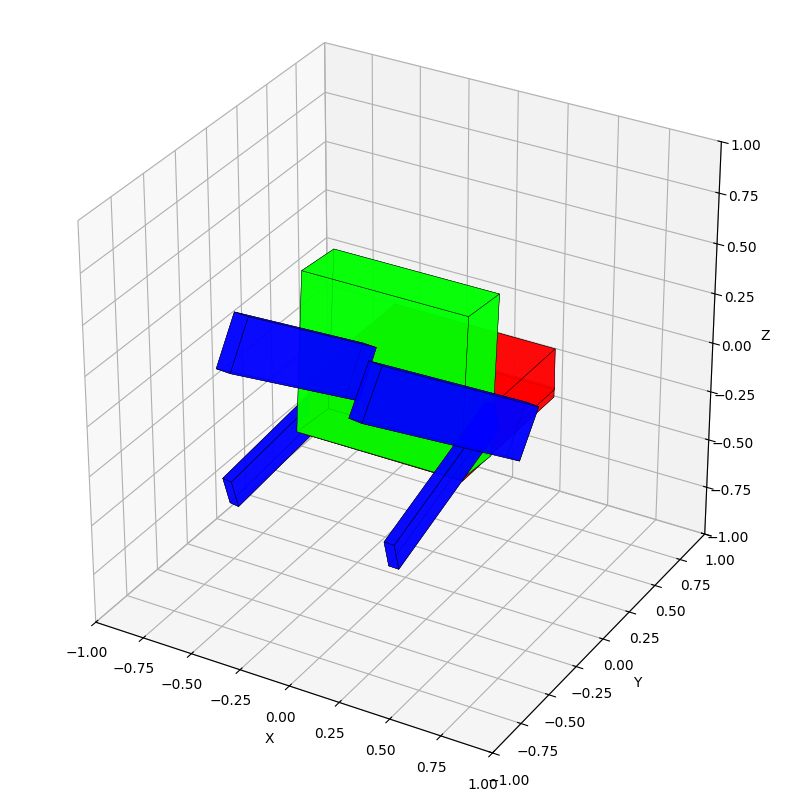

[SUCCESS] 3D plot displayed successfully.
[INFO] Expanding DSL tree for visualization...
[INFO] Found 7 total boxes after expansion.


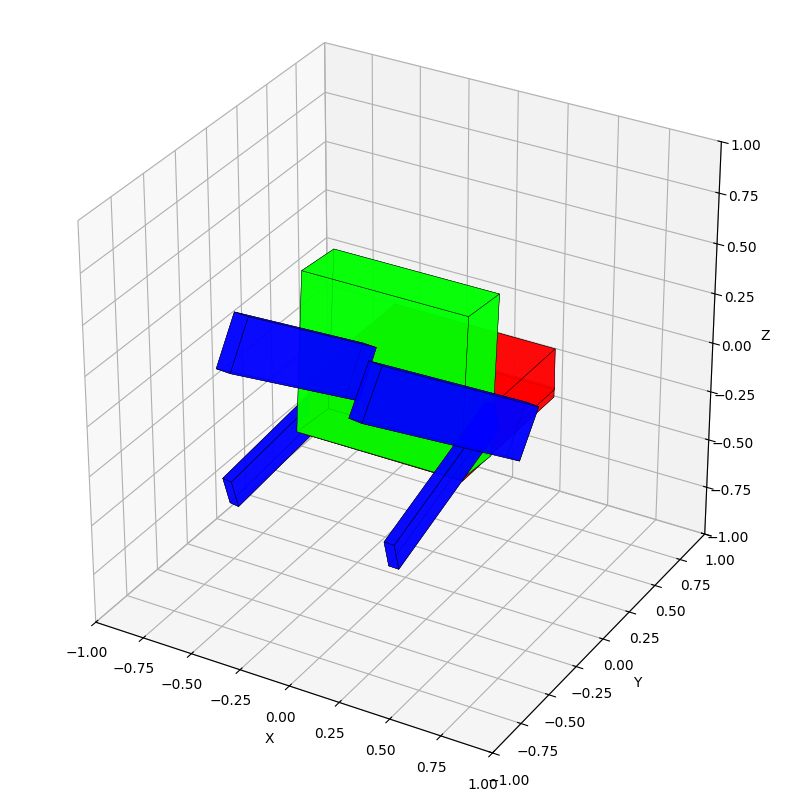

[SUCCESS] 3D plot displayed successfully.


In [121]:
import random

# --- Make sure your utility functions are available ---
# from abstractionssymh.abstraction_utils import integrate_abstractions
# from abstractionssymh.plot_utils import plot_dsl_with_matplotlib
# from abstractionssymh.debug_utils import debug_error, debug_success, debug_info

# Check that all necessary components (data and models) are loaded and ready
if all_dsl_shapes and singleton_models and pair_models:

    # --- 1. Select a Random Chair from the Dictionary ---
    # Get a list of all filenames (the dictionary keys)
    available_chair_names = list(all_dsl_shapes.keys())
    # Choose one at random
    random_chair_name = random.choice(available_chair_names)
    
    # Retrieve the DSL object using the random filename
    original_chair_dsl = all_dsl_shapes[random_chair_name]["dsl"]
    
    debug_info(f"--- Testing Abstraction on: {random_chair_name} ---")

    # --- 2. Run the Abstraction Process ---
    # This function walks the tree and replaces patterns with 'Abstraction' nodes
    abstracted_chair_dsl = integrate_abstractions(
        original_chair_dsl, 
        singleton_models, 
        pair_models, 
        error_threshold=0.01  # A stricter threshold for high-quality abstractions
    )

    # --- 3. Display Textual "Before and After" Comparison ---
    print("\n--- ORIGINAL CHAIR DSL ---")
    print(original_chair_dsl)
    
    print("\n--- ABSTRACTED CHAIR DSL ---")
    print(abstracted_chair_dsl)

    # --- 4. Generate Visual "Before and After" Comparison ---
    
    debug_info("\n--- Generating comparison plots... ---")
    
    # Define save paths for the comparison images
    comparison_dir = saved_directory / "abstraction_comparisons"
    original_save_path = comparison_dir / f"{random_chair_name.replace('.json', '_original.png')}"
    abstracted_save_path = comparison_dir / f"{random_chair_name.replace('.json', '_abstracted.png')}"
    
    # Plot and save the original chair
    # plot_dsl_with_matplotlib(original_chair_dsl, save_path=original_save_path)
    plot_dsl_with_matplotlib(original_chair_dsl)
    
    # Plot and save the abstracted chair (it should look identical)
    # plot_dsl_with_matplotlib(abstracted_chair_dsl, save_path=abstracted_save_path)
    plot_dsl_with_matplotlib(abstracted_chair_dsl)
    
else:
    debug_error("Cannot run the test: DSL shapes or trained models are missing.")

In [123]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

from abstractionssymh.dsl_nodes import (
    Box,
    Scale,
    Rotate,
    Translate,
    Union,
    SymRef,
    SymRot,
    SymTrans,
)

# ==============================================================================
# --- PART 1: DSL <-> DICTIONARY CONVERSION (Your working versions) ---
# ==============================================================================

def dsl_to_dict(node):
    """Converts your DSL node tree into a nested dictionary."""
    node_type = type(node).__name__
    if isinstance(node, Box):
        params = {"label": node.label}
        children = []
    elif isinstance(node, Scale):
        params = {"lengths": node.lengths.tolist()}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, Rotate):
        params = {"quaternion": node.quaternion.tolist()}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, Translate):
        params = {"center": node.center.tolist()}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, Union):
        params = {}
        children = [dsl_to_dict(node.left), dsl_to_dict(node.right)]
    elif isinstance(node, SymRef):
        params = {"plane": node.plane.tolist(), "point_on_plane": node.point_on_plane.tolist()}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, SymRot):
        params = {"axis": node.axis.tolist(), "center": node.center.tolist(), "n": node.n}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, SymTrans):
        params = {"end_point": node.end_point.tolist(), "n": node.n}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, Abstraction):
        params = {"pattern_name": node.pattern_name, "compressed_params": node.compressed_params}
        children = [dsl_to_dict(c) for c in node.children]
    else:
        params = {}
        children = []
    return {"type": node_type, "params": params, "children": children}

def dict_to_dsl(d, singleton_models=None, pair_models=None):
    """Converts a dictionary back into a DSL object using your trained models."""
    singleton_models = singleton_models or {}
    pair_models = pair_models or {}
    node_type = d["type"]
    params = d.get("params", {})
    children = [dict_to_dsl(c, singleton_models, pair_models) for c in d.get("children", [])]

    if node_type == "Abstraction":
        pattern_name = params.get("pattern_name")
        model = singleton_models.get(pattern_name) or pair_models.get(pattern_name)
        if model is None:
            raise ValueError(f"No trained model found for Abstraction '{pattern_name}'")
        return Abstraction(pattern_name, params["compressed_params"], model=model, children=children)
    elif node_type == "Box":
        return Box(params["label"])
    elif node_type == "Scale":
        return Scale(children[0], params["lengths"])
    elif node_type == "Rotate":
        return Rotate(children[0], params["quaternion"])
    elif node_type == "Translate":
        return Translate(children[0], params["center"])
    elif node_type == "SymRef":
        return SymRef(children[0], plane_normal=params["plane"], point_on_plane=params["point_on_plane"])
    elif node_type == "SymRot":
        return SymRot(children[0], axis=params["axis"], center=params["center"], n_fold=params["n"])
    elif node_type == "SymTrans":
        return SymTrans(children[0], end_point=params["end_point"], n_fold=params["n"])
    elif node_type == "Union":
        return Union(children[0], children[1])
    else:
        raise ValueError(f"Unknown node type in dict: {node_type}")

# ==============================================================================
# --- PART 2: THE NEW, INTUITIVE ACCORDION-ONLY WIDGET EDITOR ---
# ==============================================================================

live_output = widgets.Output()

def build_accordion_editor(data_source, update_fn):
    """
    (NEW) Recursively builds a clean, intuitive editor using only
    collapsible accordions and simple text boxes for parameters.
    """
    # --- 1. Parameter Widgets (using classic HBox with FloatText) ---
    param_widgets = []
    params_dict = data_source.get('params', {})
    for key, value in params_dict.items():
        hbox_items = [widgets.Label(value=f"{key}:", layout=widgets.Layout(width='140px'))]
        if isinstance(value, (int, float)):
            widget = widgets.FloatText(value=value, layout=widgets.Layout(width='100px'), step=0.01)
            def make_observer(source_dict, key):
                def on_value_change(change):
                    source_dict[key] = change.new
                    update_fn()
                return on_value_change
            widget.observe(make_observer(params_dict, key), names='value')
            hbox_items.append(widget)
        elif isinstance(value, list) and all(isinstance(v, (int, float)) for v in value):
            for i, num in enumerate(value):
                widget = widgets.FloatText(value=num, layout=widgets.Layout(width='100px'), step=0.01)
                def make_observer(source_list, index):
                    def on_value_change(change):
                        source_list[index] = change.new
                        update_fn()
                    return on_value_change
                widget.observe(make_observer(value, i), names='value')
                hbox_items.append(widget)
        else:
            hbox_items.append(widgets.Label(str(value)))
        param_widgets.append(widgets.HBox(hbox_items))
    
    param_box = widgets.VBox(param_widgets, layout=widgets.Layout(padding='5px 0 10px 0'))

    # --- 2. Children Node Widgets ---
    children_widgets = []
    children_list = data_source.get('children', [])
    for child_data in children_list:
        children_widgets.append(build_accordion_editor(child_data, update_fn))
    
    # --- 3. Assemble the Node Widget ---
    # Put parameters first, then the list of children widgets.
    node_content = widgets.VBox([param_box] + children_widgets)
    
    # Wrap the whole thing in a final Accordion for collapsibility.
    node_accordion = widgets.Accordion(children=[node_content])
    node_accordion.set_title(0, f"{data_source.get('type', 'Node')}")
    # Start with all nodes collapsed for a clean initial view.
    node_accordion.selected_index = None 
    
    return node_accordion

# ==============================================================================
# --- USAGE ---
# ==============================================================================

# Assume 'abstracted_chair_dsl' is your DSL object.
# Assume 'singleton_models' and 'pair_models' are your trained model dictionaries.

# 1. Convert DSL to dict
dsl_dict = dsl_to_dict(abstracted_chair_dsl)

# 2. Define the update function
def trigger_update():
    with live_output:
        clear_output(wait=True)
        # Rebuild DSL using your actual trained models
        new_dsl = dict_to_dsl(dsl_dict, singleton_models=singleton_models, pair_models=pair_models)
        plot_dsl_with_k3d(new_dsl) # Your plotting function

# 3. Build the new accordion-only editor
editor_widget = build_accordion_editor(dsl_dict, trigger_update)
editor_widget.layout = widgets.Layout(width='50%', border='1px solid #ddd', padding='5px')
live_output.layout = widgets.Layout(width='50%', padding='10px')

# 4. Display in a side-by-side layout
print("Interactive DSL Editor and Live View")
display(widgets.HBox([editor_widget, live_output]))
trigger_update()


Interactive DSL Editor and Live View


In [ ]:
# debug_info("Starting singleton model training...")
# singleton_models = find_abstractions(singleton_params, structure_type="SINGLETONS", min_examples=50, epochs=25)

# debug_info("Starting pair model training...")
# pair_models = find_abstractions(pair_params, structure_type="PAIRS", min_examples=50, epochs=25)

# debug_success(f"Training complete. {len(singleton_models)} singleton models and {len(pair_models)} pair models trained.")

In [ ]:
# if all_dsl_shapes and singleton_models and pair_models:
#     random_chair = random.choice(all_dsl_shapes)
#     # debug_info("--- ORIGINAL CHAIR ---")
#     # debug_info(f"Serialized children count: {len(random_chair.serialize()[1][1])}")
#     # debug_info(f"Preview: {random_chair}")

#     abstracted_chair = integrate_abstractions(
#         random_chair, singleton_models, pair_models, error_threshold=0.01
#     )

#     # debug_info("\n--- ABSTRACTED CHAIR ---")
#     # if isinstance(abstracted_chair, Abstraction):
#     #     debug_info(f"Abstraction pattern: {abstracted_chair.pattern_name}, compressed dim: {len(abstracted_chair.compressed_params)}")
#     # debug_info(f"Preview: {abstracted_chair}")

#     # Visualization
#     # plot_chair(random_chair)
#     # plot_chair(abstracted_chair)
# else:
#     debug_error("Cannot run test: DSL shapes or trained models are missing.")

In [ ]:
# print("Original Chair Object:")
# print(random_chair)

# print("\nAbstracted Chair Object:")
# print(abstracted_chair)

In [ ]:
# import pandas as pd
# from tqdm.notebook import tqdm

# from abstractionssymh.abstraction_compare_utils import calculate_tree_complexity_reduction, calculate_parameter_compression, calculate_abstraction_coverage
# from abstractionssymh.abstraction_compare_utils import get_point_cloud_from_dsl, calculate_chamfer_distance, plot_point_clouds_with_k3d

# all_results_with_objects = []

# # Loop through all shapes with a progress bar
# for i, original_chair in enumerate(tqdm(all_dsl_shapes[:1000], desc="Processing and Storing Chairs")):
    
#     # 1. Perform the abstraction
#     abstracted_chair = integrate_abstractions(
#         original_chair, singleton_models, pair_models, error_threshold=0.01
#     )
    
#     # 2. Calculate metrics
#     complexity = calculate_tree_complexity_reduction(original_chair, abstracted_chair)
#     compression = calculate_parameter_compression(original_chair, abstracted_chair)
#     coverage = calculate_abstraction_coverage(original_chair, abstracted_chair)

#     pc_original = get_point_cloud_from_dsl(original_chair, points_per_box=1000)
#     pc_abstracted = get_point_cloud_from_dsl(abstracted_chair, points_per_box=1000)
#     chamfer_distance = calculate_chamfer_distance(pc_original, pc_abstracted)
    
#     # 3. Store metrics AND the actual DSL objects
#     chair_result = {
#         'chair_id': i,
#         # --- Metrics ---
#         'node_reduction_%': float(complexity['metrics']['node_count_reduction'].strip('%')),
#         'depth_reduction_%': float(complexity['metrics']['max_depth_reduction'].strip('%')),
#         'param_compression_%': float(compression['metrics']['parameter_compression_ratio'].strip('%')),
#         'abstraction_coverage_%': float(coverage['metrics']['abstraction_coverage'].strip('%')),
#         'chamfer_distance': float(chamfer_distance),
#         # --- ADDING THE DSL OBJECTS ---
#         'original_chair_obj': original_chair,
#         'abstracted_chair_obj': abstracted_chair
#     }
    
#     all_results_with_objects.append(chair_result)

# print(f"\nProcessed and stored {len(all_results_with_objects)} chairs with their objects and metrics.")

# # --- Create the DataFrame ---
# # The DataFrame will now have columns containing the chair objects themselves.
# results_df_with_objects = pd.DataFrame(all_results_with_objects)

# # Display the DataFrame columns to confirm objects are stored
# print("\nDataFrame columns:", results_df_with_objects.columns.tolist())
# display(results_df_with_objects.head())

In [ ]:
# results_df_with_objects.to_csv(saved_directory / Path("full_abstraction_results.csv"))

In [ ]:
# results_df_with_objects.to_pickle(saved_directory / Path("full_abstraction_results.pkl"))

In [ ]:
# import pandas as pd

# # --- LOADING THE RESULTS ---
# # Load the entire DataFrame, including the DSL objects, back from the pickle file
# loaded_results_df = pd.read_pickle("full_abstraction_results.pkl")

# print("Successfully loaded the results DataFrame.")
# print("Columns:", loaded_results_df.columns.tolist())
# display(loaded_results_df.head())

# # Now you can access the objects just like before
# a_random_chair = loaded_results_df.sample().iloc[0]
# original_obj = a_random_chair['original_chair_obj']

# print("\nSuccessfully accessed a loaded DSL object:")
# print(original_obj)

In [ ]:
# # --- Find the chair with the highest abstraction coverage ---
# # We use idxmax() to get the index of the row with the maximum value in that column.
# # best_chair_index = results_df_with_objects['abstraction_coverage_%'].idxmax()
# best_chair_index = results_df_with_objects.sample().index[0]

# # --- Retrieve the entire row for that chair ---
# best_chair_data = results_df_with_objects.loc[best_chair_index]

# print(f"--- Inspecting Chair ID: {best_chair_data['chair_id']} (Abstraction: {best_chair_data['abstraction_coverage_%']:.2f}%) ---\n")

# # --- Access the stored objects from the DataFrame row ---
# chair_to_compare_original = best_chair_data['original_chair_obj']
# chair_to_compare_abstracted = best_chair_data['abstracted_chair_obj']

# # --- Now you can compare them directly ---

# # 1. Print the structures to see the code-level difference
# print("--- ORIGINAL CHAIR STRUCTURE ---")
# print(chair_to_compare_original)
# print("\n--- ABSTRACTED CHAIR STRUCTURE ---")
# print(chair_to_compare_abstracted)

# # 2. Plot them both to visually confirm they are identical
# print("\n--- VISUAL COMPARISON ---")
# print("Displaying Original Chair Plot:")
# plot_chair(chair_to_compare_original)

# print("Displaying Abstracted Chair Plot:")
# plot_chair(chair_to_compare_abstracted)